# PARSHO IDR0072_A single-image analysis

This notebook analyzes one configurable folder from `IDR0072_A`. The complete merged RGB image defines the cells, raw ch01 (DRAQ5) defines nuclei, and raw ch02 (EGFP) defines aggregates. Aggregate intensity is measured from the raw ch02 image only at pixels retained in the aggregate mask. Radial analysis is not performed.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cellpose import core, models
import cellpose.utils as cellpose_utils
from IPython.display import display

from parsho.img_utils import load_image
from parsho.maskfilters import (
    build_overlay,
    compute_cell_metrics,
    filter_cells_by_overlap,
    mask_overlay_to_transfected,
    subtract_nuclear_from_aggregate,
)
from parsho.plotting import (
    plot_aggregate_channel,
    plot_aggregate_channel_color,
    plot_aggregate_channel_color_labelled,
    plot_segmentation_result,
)
from parsho.segmentation import extract_masks

## Configuration

Change `IMAGE_FOLDER` to analyze a different folder.

In [11]:
DATA_DIR = Path(
    "/media/ograciac/light-roast/ograciac/MorroCells/"
    "DatasetsParsho/IDR0072_A"
)
IMAGE_FOLDER = "image-12790701"
IMAGE_DIR = DATA_DIR / IMAGE_FOLDER
RESULTS_DIR = DATA_DIR / "parsho_results" / IMAGE_FOLDER
CELL_CSV = RESULTS_DIR / "cell_metrics.csv"

NUCLEUS_MIN_SIZE = 5
AGGREGATE_MIN_SIZE = 2
REMOVE_NUCLEAR_SIGNAL_FROM_AGGREGATES = True

CELLPOSE_PARAMETERS = {
    "batch_size": 32,
    "diameter": None,
    "flow_threshold": 0.4,
    "cellprob_threshold": -2.0,
    "min_size": 15,
    "normalize": {"tile_norm_blocksize": 0},
}

In [12]:
GPU = core.use_gpu()
print(f"Using GPU: {GPU}")
model = models.CellposeModel(gpu=GPU)

Using GPU: True


## Load the merged, nuclear, and aggregate images

In [13]:
merged_path = IMAGE_DIR / f"{IMAGE_FOLDER}_merged_z0_t0.jpg"
nucleus_path = IMAGE_DIR / f"{IMAGE_FOLDER}_ch01_DRAQ5_z0_t0_raw.tif"
aggregate_path = IMAGE_DIR / f"{IMAGE_FOLDER}_ch02_EGFP_z0_t0_raw.tif"

merged_image = load_image(merged_path)
nucleus_channel = load_image(nucleus_path)
aggregate_channel = load_image(aggregate_path)

if merged_image.shape[:2] != nucleus_channel.shape:
    raise ValueError("Merged and raw channel images must have the same size")
if nucleus_channel.shape != aggregate_channel.shape:
    raise ValueError("Raw ch01 and ch02 images must have the same size")

print(f"Merged: {merged_image.shape} {merged_image.dtype}")
print(f"ch01 nucleus: {nucleus_channel.shape} {nucleus_channel.dtype}")
print(f"ch02 aggregates: {aggregate_channel.shape} {aggregate_channel.dtype}")

Merged: (1002, 1347, 3) uint8
ch01 nucleus: (1002, 1347) uint16
ch02 aggregates: (1002, 1347) uint16


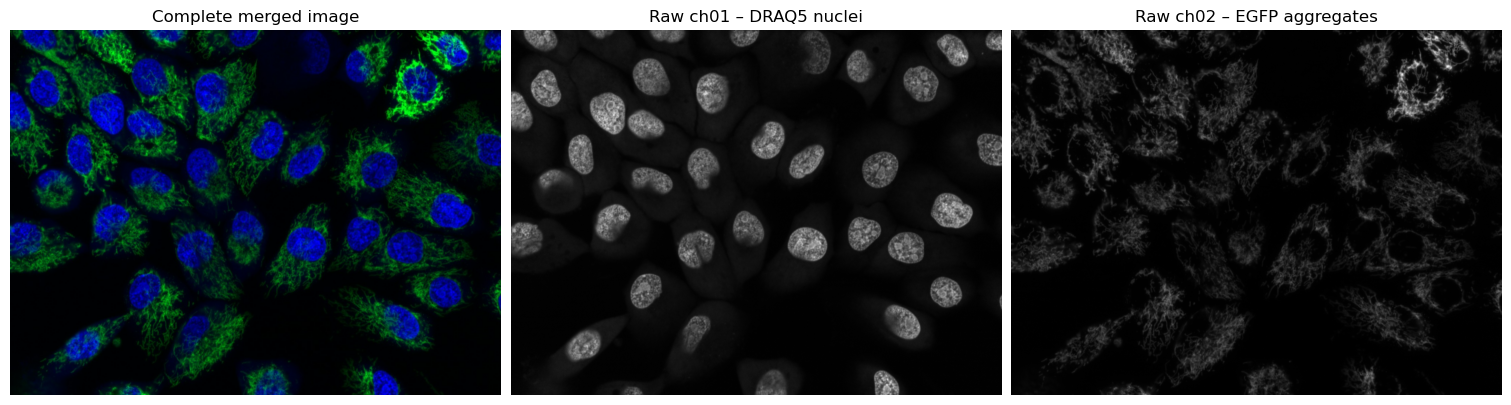

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
axes[0].imshow(merged_image)
axes[0].set_title("Complete merged image")
axes[1].imshow(nucleus_channel, cmap="gray")
axes[1].set_title("Raw ch01 – DRAQ5 nuclei")
axes[2].imshow(aggregate_channel, cmap="gray")
axes[2].set_title("Raw ch02 – EGFP aggregates")
for axis in axes:
    axis.axis("off")
plt.show()

## Segment cells from the complete merged image

The RGB merge is passed intact to Cellpose.

Detected 40 cells


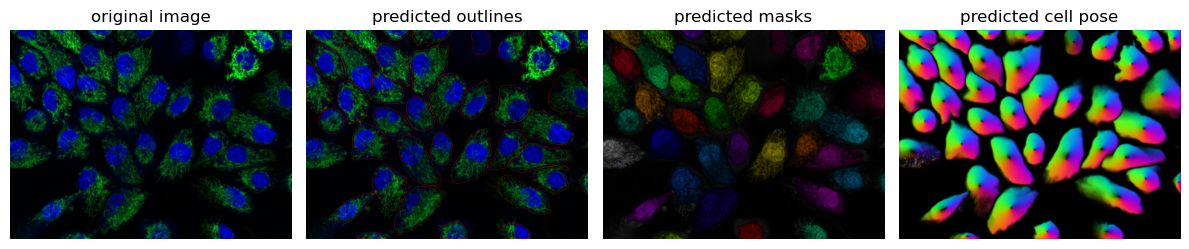

In [15]:
cell_masks, cell_flows, _ = model.eval(
    merged_image,
    channel_axis=-1,
    **CELLPOSE_PARAMETERS,
)
if not np.any(cell_masks):
    raise ValueError(f"Cellpose detected no cells in {IMAGE_FOLDER}")
print(f"Detected {int(cell_masks.max())} cells")
plot_segmentation_result(merged_image, cell_masks, cell_flows)

## Detect nuclei and aggregates

Nucleus Otsu threshold: 174.693359375
Aggregate Otsu threshold: 377.2890625
Nuclear mask


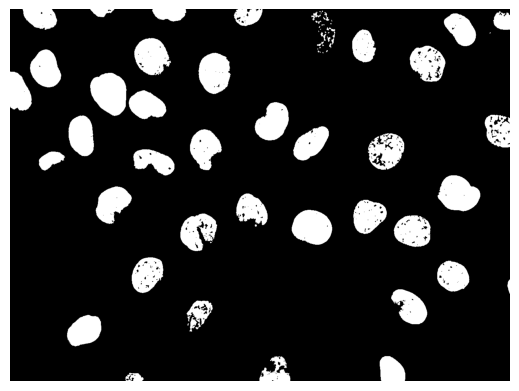

Aggregate mask


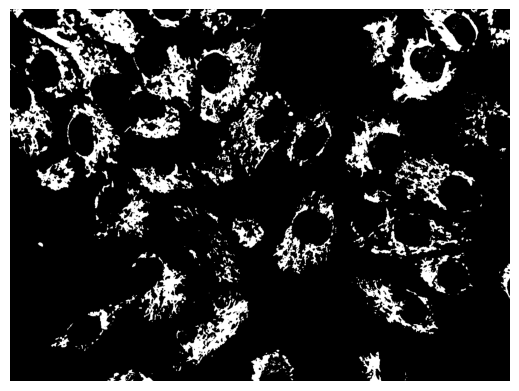

In [16]:
nuc_binary, nuc_labels, nucleus_threshold = extract_masks(
    aggregate_channel=nucleus_channel,
    cell_masks=cell_masks,
    method="otsu",
    min_size_px=NUCLEUS_MIN_SIZE,
)
agg_binary, agg_labels, aggregate_threshold = extract_masks(
    aggregate_channel=aggregate_channel,
    cell_masks=cell_masks,
    method="otsu",
    min_size_px=AGGREGATE_MIN_SIZE,
)
if REMOVE_NUCLEAR_SIGNAL_FROM_AGGREGATES:
    agg_binary, agg_labels = subtract_nuclear_from_aggregate(
        agg_binary, agg_labels, nuc_binary
    )

print(f"Nucleus Otsu threshold: {nucleus_threshold}")
print(f"Aggregate Otsu threshold: {aggregate_threshold}")
print("Nuclear mask")
plot_aggregate_channel(nuc_binary)
print("Aggregate mask")
plot_aggregate_channel(agg_binary)

## Retain nucleated cells and inspect the overlay

Retained 39 of 40 cells with nuclear signal


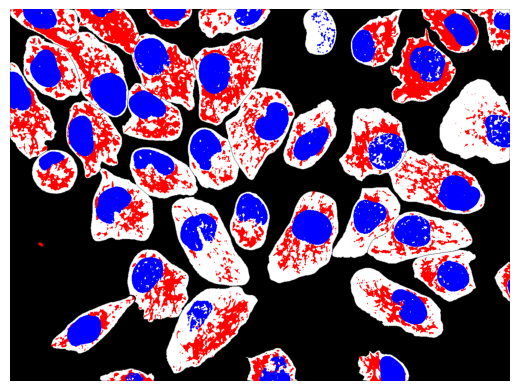

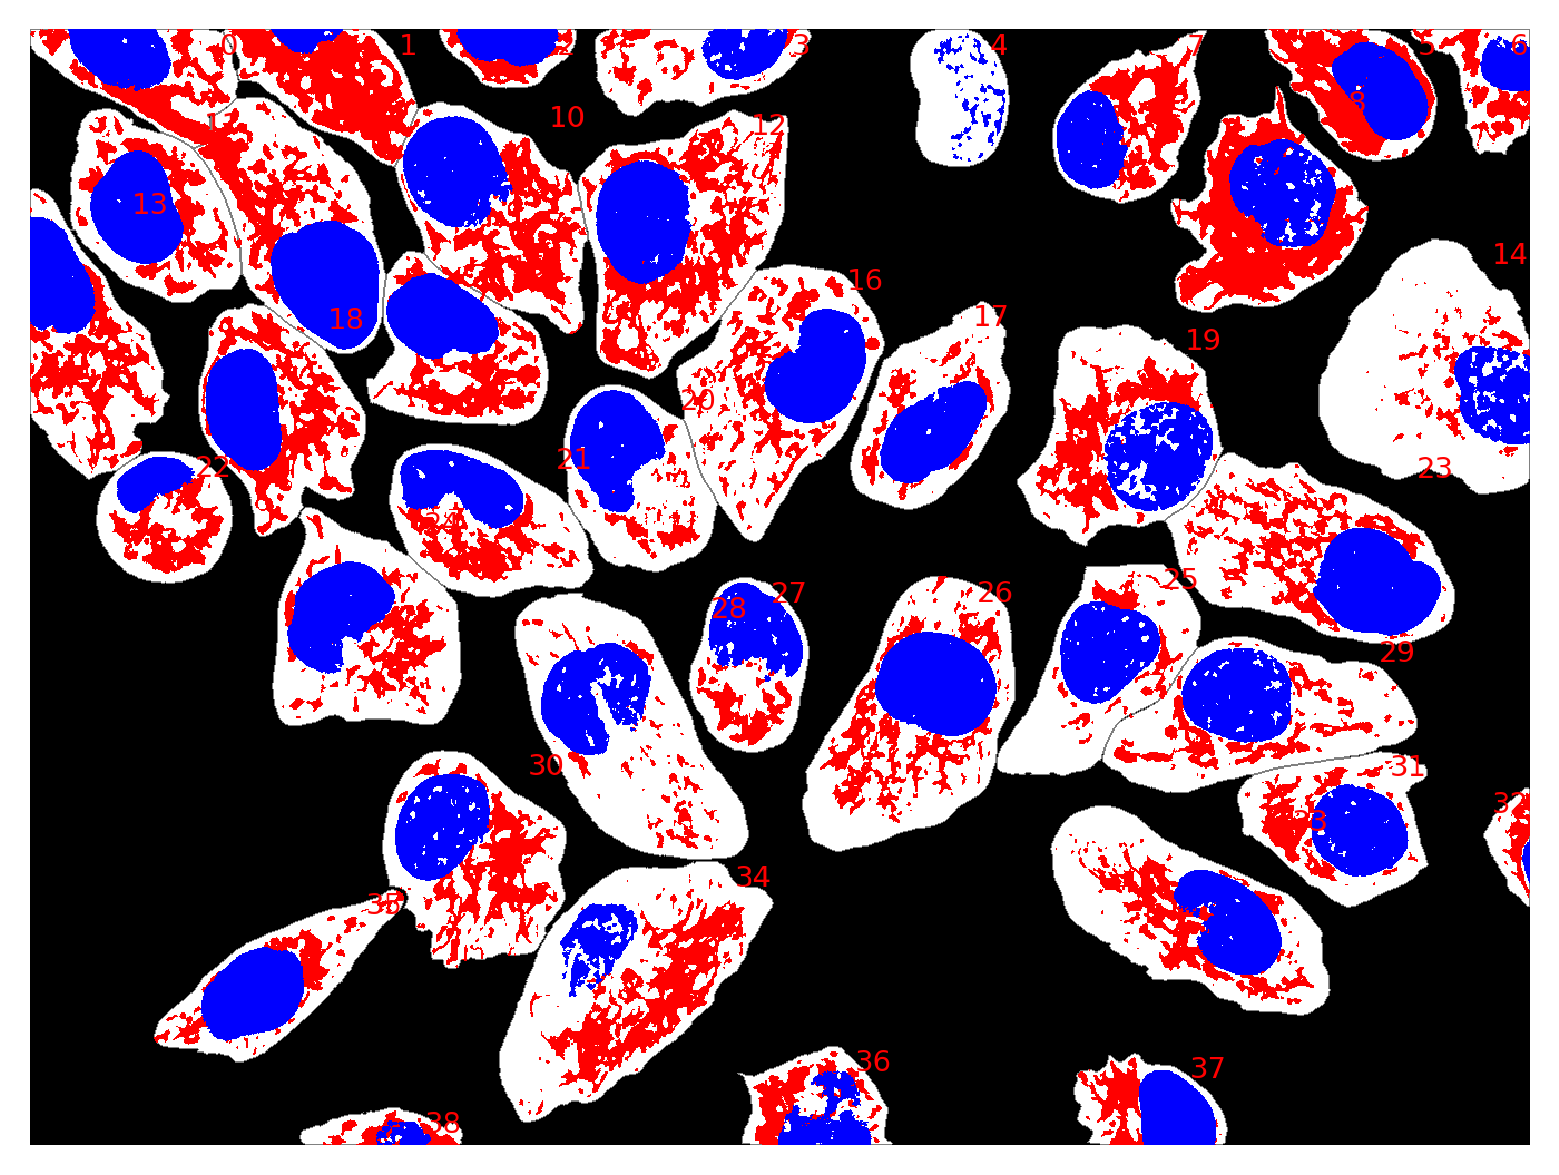

In [17]:
retained_labels = filter_cells_by_overlap(cell_masks, nuc_labels)
display_numbers = {
    cell_label: number for number, cell_label in enumerate(retained_labels)
}
outlines = cellpose_utils.masks_to_outlines(cell_masks)
overlay = build_overlay(cell_masks, nuc_labels, agg_labels, outlines)
filtered_overlay = mask_overlay_to_transfected(
    overlay, cell_masks, retained_labels
)
print(
    f"Retained {len(retained_labels)} of {int(cell_masks.max())} cells "
    "with nuclear signal"
)
plot_aggregate_channel_color(overlay)
plot_aggregate_channel_color_labelled(
    filtered_overlay, cell_masks, display_numbers
)

## Per-cell morphology and aggregate intensity

For each retained cell, aggregate intensity is measured from raw ch02 values where both the cell mask and aggregate mask are nonzero. The sum is integrated aggregate intensity; the mean describes aggregate brightness independently of aggregate area.

In [18]:
metrics = compute_cell_metrics(
    cell_masks, nuc_labels, agg_labels, retained_labels
)
records = []
for metric in metrics:
    aggregate_pixels = (
        (cell_masks == metric.label) & (agg_labels != 0)
    )
    aggregate_values = np.asarray(
        aggregate_channel[aggregate_pixels], dtype=np.float64
    )
    aggregate_intensity_sum = float(aggregate_values.sum())
    aggregate_intensity_mean = (
        float(aggregate_values.mean()) if aggregate_values.size else 0.0
    )
    records.append(
        {
            "image folder": IMAGE_FOLDER,
            "cell number": display_numbers[metric.label],
            "cell label": metric.label,
            "cell area": metric.cell_area,
            "aggregate area": metric.agg_area,
            "nucleus area": metric.nuc_area,
            "aggregate coverage fraction": metric.jaccard,
            "aggregate intensity sum": aggregate_intensity_sum,
            "aggregate intensity mean": aggregate_intensity_mean,
            "cell aspect ratio": metric.cell_aspect_ratio,
            "cell circularity": metric.cell_circularity,
            "aggregate aspect ratio": metric.agg_aspect_ratio,
            "aggregate circularity": metric.agg_circularity,
            "nucleus otsu threshold": float(nucleus_threshold),
            "aggregate otsu threshold": float(aggregate_threshold),
        }
    )
cell_data = pd.DataFrame(records)
display(cell_data)

,image folder,cell number,cell label,cell area,aggregate area,nucleus area,aggregate coverage fraction,aggregate intensity sum,aggregate intensity mean,cell aspect ratio,cell circularity,aggregate aspect ratio,aggregate circularity,nucleus otsu threshold,aggregate otsu threshold
0,image-12790701,0,1,12603,4240,3909,0.336428,2629276.0,620.112264,2.062,0.601,2.020778,1.804000,174.693359,377.289062
1,image-12790701,1,2,13058,8733,870,0.668785,6953272.0,796.206573,1.904,0.634,inf,0.802200,174.693359,377.289062
2,image-12790701,2,3,4866,1229,2398,0.252569,785435.0,639.084622,2.093,0.639,3.115000,0.198500,174.693359,377.289062
3,image-12790701,3,4,11285,1616,2560,0.143199,842161.0,521.139233,2.744,0.571,inf,0.990588,174.693359,377.289062
4,image-12790701,4,5,9116,0,1100,0.000000,0.0,0.000000,1.475,0.827,0.000000,0.000000,174.693359,377.289062
5,image-12790701,5,6,12651,5138,4969,0.406134,5297910.0,1031.123005,1.574,0.733,inf,0.783400,174.693359,377.289062
6,image-12790701,6,7,7172,2177,1763,0.303542,1298278.0,596.361047,1.573,0.537,inf,0.364286,174.693359,377.289062
7,image-12790701,7,8,14068,4736,4189,0.336651,3203086.0,676.327280,1.481,0.675,inf,7.002000,174.693359,377.289062
8,image-12790701,8,9,22027,10290,6278,0.467154,10648402.0,1034.830126,1.187,0.568,inf,1.093333,174.693359,377.289062
9,image-12790701,9,10,24294,6082,8503,0.250350,3386109.0,556.742683,2.020,0.681,inf,4.141920,174.693359,377.289062


## Save measurements and inspection figures

In [19]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
cell_data.to_csv(CELL_CSV, index=False)
plot_segmentation_result(
    merged_image,
    cell_masks,
    cell_flows,
    save_path=RESULTS_DIR / "cell_segmentation.png",
)
plot_aggregate_channel(
    nuc_binary, save_path=RESULTS_DIR / "nuclear_mask.png"
)
plot_aggregate_channel(
    agg_binary, save_path=RESULTS_DIR / "aggregate_mask.png"
)
plot_aggregate_channel_color(
    overlay, save_path=RESULTS_DIR / "all_cells_overlay.png"
)
plot_aggregate_channel_color_labelled(
    filtered_overlay,
    cell_masks,
    display_numbers,
    save_path=RESULTS_DIR / "retained_cells.png",
)
print(f"Saved {len(cell_data)} cell rows to {CELL_CSV}")

Saved 39 cell rows to /media/ograciac/light-roast/ograciac/MorroCells/DatasetsParsho/IDR0072_A/parsho_results/image-12790701/cell_metrics.csv


## Outputs

The notebook writes `cell_metrics.csv` plus segmentation, nuclear-mask, aggregate-mask, and overlay figures under `IDR0072_A/parsho_results/<IMAGE_FOLDER>/`.